<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/CL_GradCAM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dataset URL: https://www.kaggle.com/datasets/saniyaverma914/cropdg-unified-multidomain
License(s): CC-BY-NC-SA-4.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Classes: ['Blight', 'Healthy', 'Leaf_spot', 'Viral']
Model loaded successfully.
===== IID (PV) Samples =====


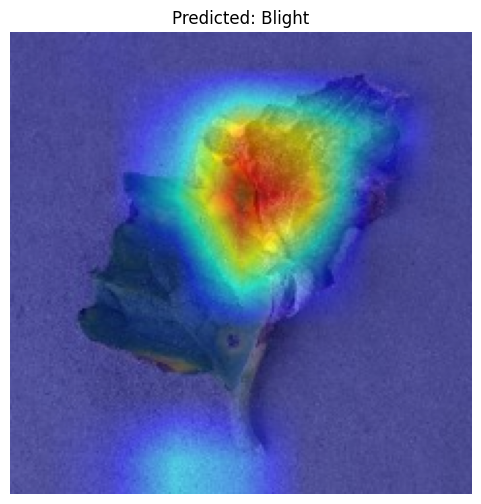

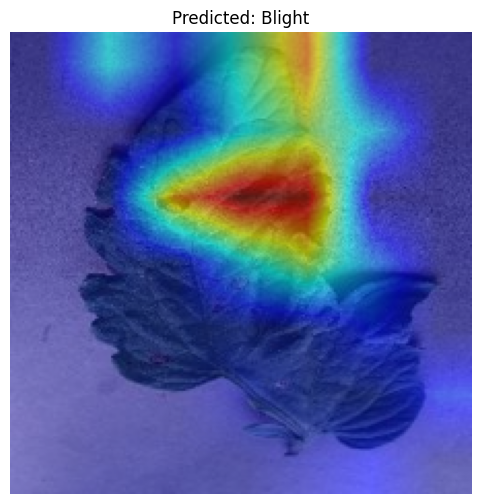

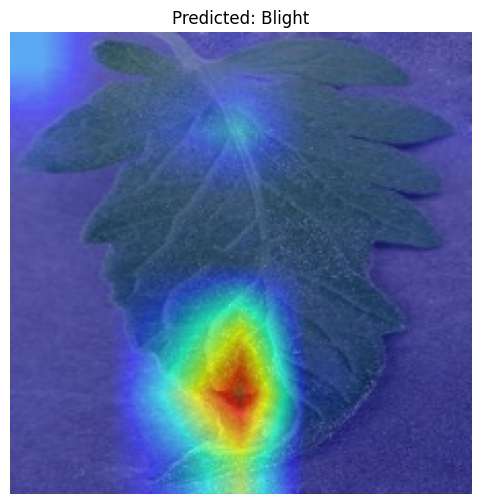

===== OOD (PD) Samples =====


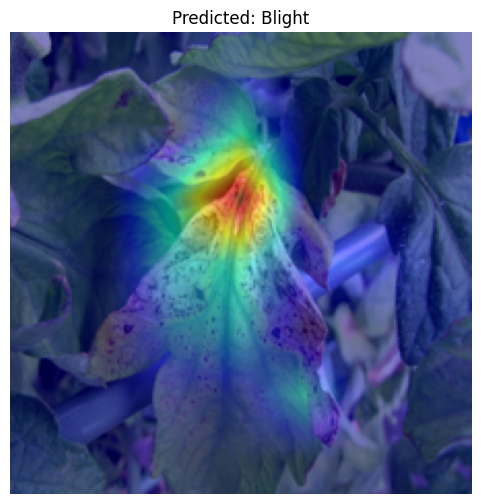

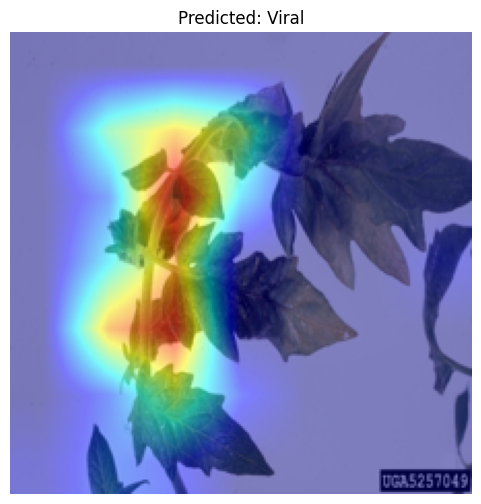

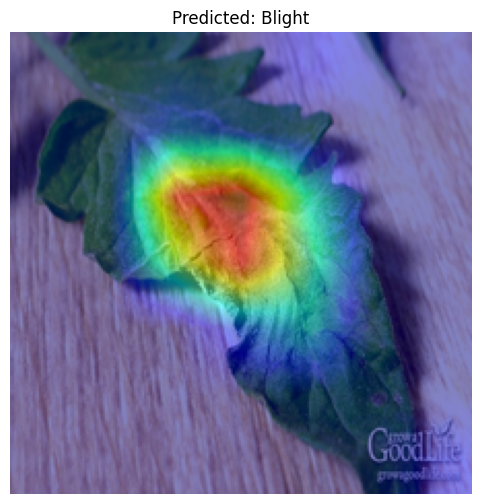

In [ ]:
# ============================================================
# Grad-CAM Analysis | Centralized ConvNeXt-Tiny (Tomato)
# ============================================================

# =========================
# 1️⃣ Install Grad-CAM
# =========================
!pip install grad-cam -q

# =========================
# 2️⃣ Dataset Download
# =========================
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d saniyaverma914/cropdg-unified-multidomain -q
!unzip -q cropdg-unified-multidomain.zip

# =========================
# 3️⃣ Imports
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# =========================
# 4️⃣ Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 5️⃣ Paths
# =========================
BASE_DIR = "/content"

PV_TOMATO   = os.path.join(BASE_DIR, "PV", "Tomato")
CCMT_TOMATO = os.path.join(BASE_DIR, "CCMT", "Tomato")
PD_TOMATO   = os.path.join(BASE_DIR, "PD", "Tomato")

checkpoint_path = "/content/drive/MyDrive/convneXt-tiny_checkpoint.pth"

# =========================
# 6️⃣ Collect Samples
# =========================
def collect_samples(root_dir, class_to_idx=None):
    samples = []

    if class_to_idx is None:
        classes = sorted(os.listdir(root_dir))
        class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    else:
        classes = list(class_to_idx.keys())

    for cls in classes:
        class_path = os.path.join(root_dir, cls)
        if not os.path.isdir(class_path):
            continue

        for img in os.listdir(class_path):
            samples.append({
                "path": os.path.join(class_path, img),
                "label": class_to_idx[cls],
                "class_name": cls
            })

    return samples, class_to_idx


# Build mapping from PV
pv_samples, class_to_idx = collect_samples(PV_TOMATO)
ccmt_samples, _ = collect_samples(CCMT_TOMATO, class_to_idx)
pd_samples, _   = collect_samples(PD_TOMATO, class_to_idx)

class_names = list(class_to_idx.keys())
num_classes = len(class_names)

print("Classes:", class_names)

# =========================
# 7️⃣ Model Reconstruction
# =========================
model = models.convnext_tiny(weights=None)

model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    num_classes
)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["best_model_state"])

model = model.to(device)
model.eval()

print("Model loaded successfully.")

# =========================
# 8️⃣ EXACT SAME TEST TRANSFORM
# =========================
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# =========================
# 9️⃣ Grad-CAM Setup
# =========================
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# =========================
# 🔟 Grad-CAM Function
# =========================
def run_gradcam(sample):
    img = Image.open(sample["path"]).convert("RGB")
    img_resized = img.resize((224,224))
    img_np = np.array(img_resized) / 255.0

    input_tensor = test_transform(img).unsqueeze(0).to(device)

    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6,6))
    plt.imshow(visualization)
    plt.title(f"Predicted: {class_names[pred_class]}")
    plt.axis("off")
    plt.show()

# =========================
# 1️⃣1️⃣ Run on Few IID & OOD
# =========================
print("===== IID (PV) Samples =====")
for i in range(3):
    run_gradcam(pv_samples[i])

print("===== OOD (PD) Samples =====")
for i in range(3):
    run_gradcam(pd_samples[i])